In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose

In [3]:
df = pd.read_csv("cleaned_supply_chain_dataset.csv")

In [5]:
df.head()

,Date,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Competitor Pricing
0,2024-01-01,161.666667,372,471,365,345.355000,13.333333,335.860000
1,2024-01-02,188.000000,285,424,269,387.343333,11.666667,384.681667
2,2024-01-03,174.500000,337,390,325,412.145000,9.166667,409.808333
3,2024-01-04,169.500000,378,378,378,435.063333,9.166667,441.626667
4,2024-01-05,191.833333,337,438,349,326.791667,5.833333,338.005000


In [7]:
df["Date"] = pd.to_datetime(df["Date"])

In [9]:
df = df.set_index("Date")

In [11]:
df.head()

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Competitor Pricing
Date,,,,,,,
2024-01-01,161.666667,372,471,365,345.355000,13.333333,335.860000
2024-01-02,188.000000,285,424,269,387.343333,11.666667,384.681667
2024-01-03,174.500000,337,390,325,412.145000,9.166667,409.808333
2024-01-04,169.500000,378,378,378,435.063333,9.166667,441.626667
2024-01-05,191.833333,337,438,349,326.791667,5.833333,338.005000


In [13]:
df.isnull().sum()

Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Competitor Pricing    0
dtype: int64

In [15]:
ts = df["Units Sold"]

In [17]:
ts.head()

Date
2024-01-01    372
2024-01-02    285
2024-01-03    337
2024-01-04    378
2024-01-05    337
Name: Units Sold, dtype: int64

In [19]:
result = seasonal_decompose(
    ts,
    model="additive",
    period=7
)

In [21]:
trend = result.trend

seasonal = result.seasonal

residual = result.resid

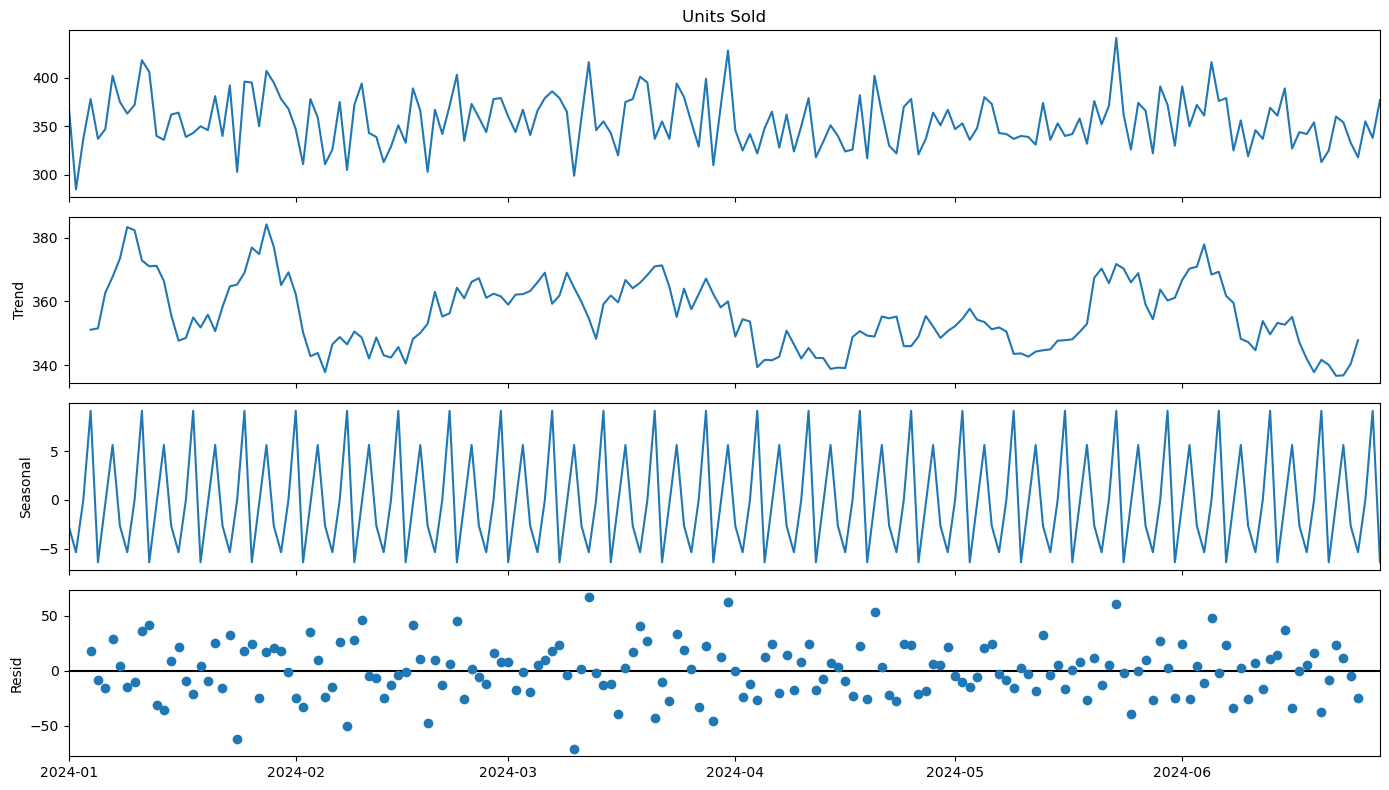

In [23]:
fig = result.plot()

fig.set_size_inches(14,8)

plt.tight_layout()

plt.show()

In [25]:
fig.savefig(
    "decomposition_full.png",
    dpi=300
)

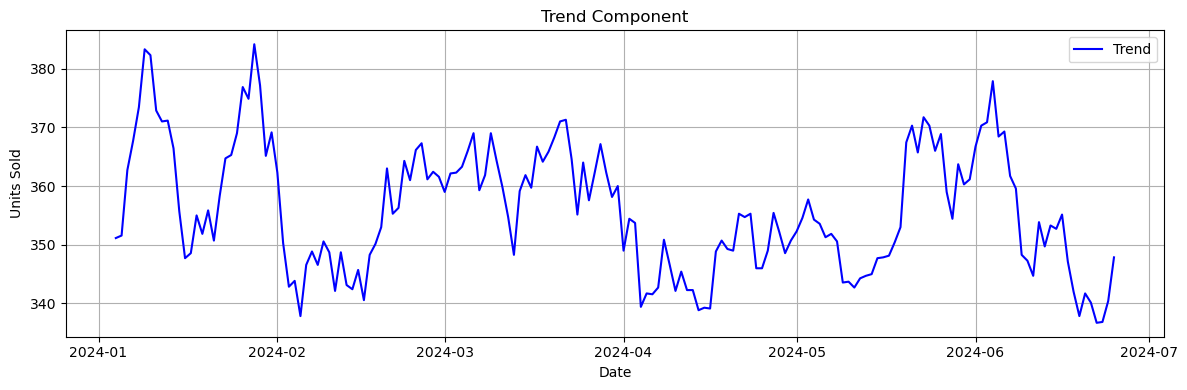

In [27]:
plt.figure(figsize=(12,4))

plt.plot(
    trend,
    color="blue",
    label="Trend"
)

plt.title("Trend Component")

plt.xlabel("Date")

plt.ylabel("Units Sold")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig("trend_plot.png")

plt.show()

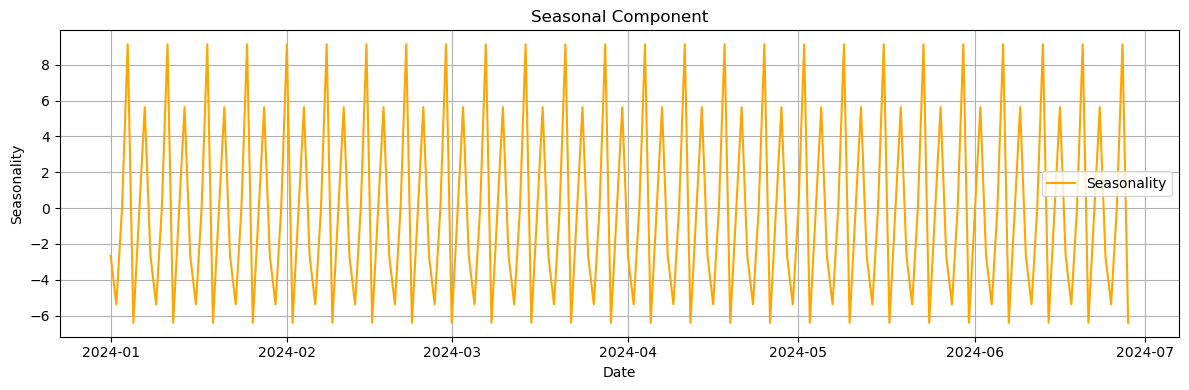

In [29]:
plt.figure(figsize=(12,4))

plt.plot(
    seasonal,
    color="orange",
    label="Seasonality"
)

plt.title("Seasonal Component")

plt.xlabel("Date")

plt.ylabel("Seasonality")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig("seasonal_plot.png")

plt.show()

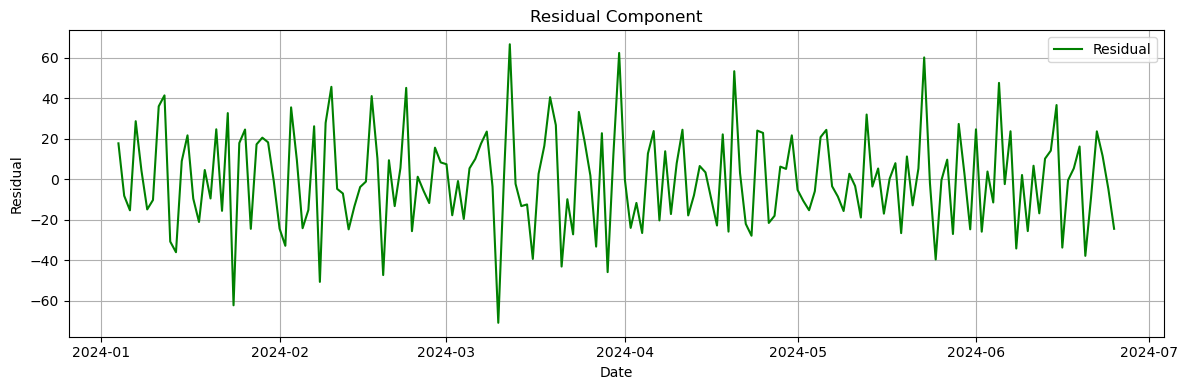

In [31]:
plt.figure(figsize=(12,4))

plt.plot(
    residual,
    color="green",
    label="Residual"
)

plt.title("Residual Component")

plt.xlabel("Date")

plt.ylabel("Residual")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

In [33]:
trend.to_csv("trend_component.csv")

seasonal.to_csv("seasonal_component.csv")

residual.to_csv("residual_component.csv")

In [35]:
trend.head()

Date
2024-01-01           NaN
2024-01-02           NaN
2024-01-03           NaN
2024-01-04    351.142857
2024-01-05    351.571429
Name: trend, dtype: float64

In [37]:
seasonal.head()

Date
2024-01-01   -2.659014
2024-01-02   -5.367585
2024-01-03   -0.005918
2024-01-04    9.140986
2024-01-05   -6.396156
Name: seasonal, dtype: float64

In [39]:
residual.head()

Date
2024-01-01          NaN
2024-01-02          NaN
2024-01-03          NaN
2024-01-04    17.716156
2024-01-05    -8.175272
Name: resid, dtype: float64